# Reducing Confounding in an Observational Drug Study with PROC PSMATCH

## Executive Summary

In a non-randomized post-marketing registry, patients who receive an add-on therapy differ systematically from those who do not, so a naive outcome comparison is confounded. This notebook builds a synthetic 100-patient Type 2 diabetes registry, estimates propensity scores with `PROC PSMATCH`, performs greedy nearest-neighbor matching within a caliper (exact on sex), assesses covariate balance before and after matching with the `ASSESS` statement, and estimates the treatment effect on the matched cohort. A propensity-score stratification of the full sample is included as a complementary design.

The naive add-on benefit is **-0.42 percentage points** of HbA1c (p = 0.0002). After 1:1 caliper matching on the logit propensity score (32 matched pairs), the effect attenuates to **-0.36** by t test (p = 0.015) and **-0.32** from the covariate-adjusted GLM (p = 0.030) — both more conservative than the raw estimate, consistent with the simulated true effect of -0.4.

## Data Sources

All data are generated inline by a DATA step — no external or network inputs.

| Dataset | Rows | Key variables | Description |
|---------|------|---------------|-------------|
| `registry` | 100 | `PatientID`, `Therapy` (`Addon`/`Standard`), `Age`, `BMI`, `BaselineHbA1c`, `Sex`, `Comorbidity`, `HbA1cChange` | Synthetic Type 2 diabetes registry. Treatment assignment depends on baseline covariates (confounding by indication); `HbA1cChange` is the outcome (6-month change in HbA1c, negative = improvement), with a true add-on benefit of -0.4 percentage points layered on top of confounder-driven differences. |

# Reducing Confounding in an Observational Drug Study with PROC PSMATCH

In a randomized controlled trial, treatment assignment is independent of patient characteristics, so a simple group comparison estimates the causal effect. Post-marketing **registry** data are different: clinicians choose who receives a new add-on therapy, often steering it toward sicker patients. This **confounding by indication** biases any naive comparison of outcomes.

`PROC PSMATCH` addresses this by (1) modeling the probability of treatment (the *propensity score*) from baseline covariates, (2) matching treated patients to comparable untreated patients on that score, and (3) verifying that the matched groups are balanced before any outcome is examined. We work through this pipeline on a synthetic Type 2 diabetes registry.

## Step 1 — Build a synthetic patient registry

We simulate 100 patients. Baseline covariates (age, BMI, baseline HbA1c, sex, comorbidity burden) drive a treatment-assignment model, so add-on patients tend to start with higher HbA1c and BMI. The 6-month change in HbA1c is the outcome: it depends on the same confounders **plus** a genuine add-on benefit of -0.4 percentage points. The assignment model is calibrated so roughly half the cohort receives the add-on, giving both arms enough patients to match and to populate propensity-score strata.

In [1]:
data registry;
   call streaminit(20260531);
   do PatientID = 1 to 100;
      /* Baseline covariates */
      Age = round(45 + 15*rand("uniform") + 5*rand("normal"));
      if Age < 35 then Age = 35;
      if Age > 80 then Age = 80;

      BMI = round(26 + 6*rand("uniform") + 2*rand("normal"), 0.1);
      if BMI < 18 then BMI = 18;

      BaselineHbA1c = round(7.2 + 0.02*(Age-55) + 0.04*(BMI-30)
                            + 0.5*rand("normal"), 0.1);
      if BaselineHbA1c < 6 then BaselineHbA1c = 6;

      if rand("uniform") < 0.50 then Sex = "M";
      else Sex = "F";

      Comorbidity = rand("bernoulli", 0.30);

      /* Treatment-assignment model: sicker, heavier, older patients
         are somewhat more likely to receive the add-on therapy
         (confounding by indication). Calibrated so roughly half the
         cohort is treated and both arms are well populated. */
      lp = -0.2 + 0.04*(Age-55) + 0.10*(BMI-28)
           + 0.80*(BaselineHbA1c-7.2) + 0.60*Comorbidity
           + 0.40*(Sex="M");
      pTreat = 1 / (1 + exp(-lp));
      Therapy = ifc(rand("uniform") < pTreat, "Addon   ", "Standard");

      /* Outcome: 6-month change in HbA1c (negative = improvement).
         Confounders dampen the response; the add-on adds a real
         -0.4 percentage-point benefit on top. */
      HbA1cChange = -0.5 - 0.30*(BaselineHbA1c-7) + 0.02*(Age-55)
                    + 0.15*Comorbidity
                    + (Therapy="Addon")*(-0.4)
                    + 0.5*rand("normal");
      HbA1cChange = round(HbA1cChange, 0.01);

      keep PatientID Therapy Age BMI BaselineHbA1c Sex
           Comorbidity HbA1cChange;
      output;
   end;
run;

proc print data=registry(obs=8) noobs;
   var PatientID Therapy Sex Age BMI BaselineHbA1c Comorbidity HbA1cChange;
run;



PATIENTID   THERAPY  SEX  AGE   BMI  BASELINEHBA1C  COMORBIDITY  HBA1CCHANGE
---------  --------  ---  ---  ----  -------------  -----------  -----------
        1  Addon     F     60  29.5            7.2            0        -0.37
        2  Addon     M     57  27.6            6.6            0        -0.86
        3  Standard  F     52  26.8            7.3            0         -0.5
        4  Standard  F     66  30.5            7.6            0        -0.21
        5  Standard  F     37  26.9            6.5            0        -0.52
        6  Standard  M     65  28.2            7.9            0        -0.63
        7  Standard  F     41  28.7            6.3            0        -0.17
        8  Standard  F     46    28              7            0        -0.31

... 92 more observations (showing 8 of 100)



NOTE: DATA registry


NOTE: Wrote registry (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=registry

NOTE: PROC PRINT completed: 8 observations printed, 8 variables


## Step 2 — Quantify the naive (confounded) comparison

Before any adjustment, compare the outcome between groups with a two-sample t test. This estimate is biased because the add-on group is systematically sicker at baseline. We will revisit this number after matching to see how much of the apparent effect was confounding.

               The TTEST Procedure                
              Variable:  HbA1cChange              

Therapy            N      Mean   Std Dev   Std Err
----------  --------  --------  --------  --------
Addon             52   -1.0173    0.5281    0.0732
Standard          48   -0.6012    0.5266    0.0760
Diff (1-2)             -0.4161                    

Therapy     Lower CL Mean      Mean  Upper CL Mean  Lower CL Std Dev   Std Dev  Upper CL Std Dev
----------  -------------  --------  -------------  ----------------  --------  ----------------
Addon             -1.1643   -1.0173        -0.8703            0.4426    0.5281            0.6550
Standard          -0.7542   -0.6012        -0.4483            0.4384    0.5266            0.6597
Diff (1-2)        -0.6256   -0.4161        -0.2066            0.4628    0.5274            0.6132

Method         Variances        DF   t Value  Pr > |t|
-------------  ---------  --------  --------  --------
Pooled         Equal            98     -3.94 

NOTE: PROC TTEST data=registry

NOTE: ODS plot written: ttest_summary.spec.json
NOTE: PROC TTEST ODS Graphics generated.
NOTE: PROC TTEST statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


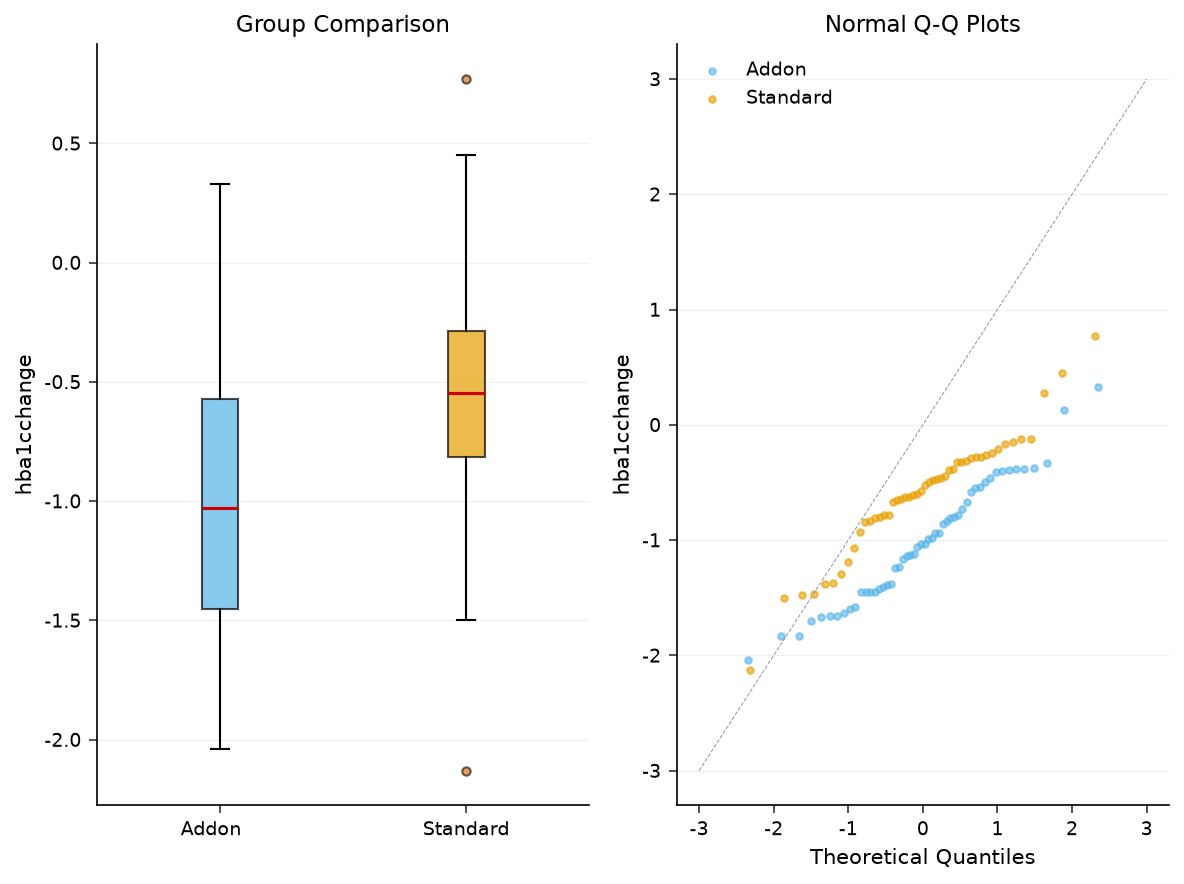

In [2]:
proc ttest data=registry;
   class Therapy;
   var HbA1cChange;
run;

proc means data=registry mean std n maxdec=2;
   class Therapy;
   var Age BMI BaselineHbA1c HbA1cChange;
run;

## Step 3 — Estimate propensity scores and match

Now the core analysis. `PROC PSMATCH`:

- **`PSMODEL Therapy(Treated='Addon') = ...`** fits a logistic regression for the probability of receiving the add-on therapy from the baseline covariates.
- **`REGION=CS`** restricts the analysis to the region of *common support* — propensity-score values where both groups are represented — so we never match patients who have no comparable counterpart.
- **`MATCH METHOD=GREEDY(K=1)`** pairs each treated patient with the single closest control, **`DISTANCE=LPS`** measures closeness on the logit of the propensity score, **`CALIPER=0.25`** rejects any match farther than 0.25 pooled standard deviations apart, and **`EXACT=Sex`** forces matched pairs to share the same sex.
- **`ASSESS`** reports standardized mean differences for each covariate and for the propensity score, before and after matching — the central balance diagnostic.
- **`OUTPUT OUT(OBS=MATCH)=`** writes only the matched observations, tagging each with its match-set ID, propensity score, and matching weight.

The `Standardized Mean Differences (Assessment)` table is what we read for balance: the propensity score (PS) and its logit (LPS) start at 0.18 and 0.16 and fall to 0.07 and 0.06 after matching — both well under the conventional 0.1 threshold. The individual covariates are already fairly balanced in this cohort (all |std diff| < 0.25 pre-match); matching keeps them small. We visualize this table explicitly in the next two cells.

In [3]:
ods graphics on;

proc psmatch data=registry region=cs;
   class Therapy Sex Comorbidity;
   psmodel Therapy(Treated='Addon') =
           Sex Comorbidity Age BMI BaselineHbA1c;
   match method=greedy(k=1) distance=lps
         caliper=0.25 exact=Sex weight=matchwgt;
   assess lps var=(Age BMI BaselineHbA1c Comorbidity);
   output out(obs=match)=matched
          ps=_ps_ lps=_lps_ matchid=_MatchID weight=_MatchWgt;
run;

/* Full-cohort propensity scores (every patient) for the
   overlap plot below. */
proc psmatch data=registry region=allobs noprint;
   class Therapy Sex Comorbidity;
   psmodel Therapy(Treated='Addon') =
           Sex Comorbidity Age BMI BaselineHbA1c;
   match method=greedy(k=1) distance=lps caliper=0.25 exact=Sex;
   output out(obs=all)=allps ps=_ps_;
run;

ods graphics off;


                        The PSMATCH Procedure                         


Standardized Mean Differences (Assessment)
------------------------------------------------------------
Variable                     Pre-Match       Post-Match
Propensity Score (PS)             0.1754         0.0664
Logit PS (LPS)                    0.1624         0.0619
Age                               0.0477        -0.1506
BMI                               0.0116        -0.0210
BaselineHbA1c                    -0.0086         0.1405
Comorbidity                       0.0561        -0.0816



Data Information
------------------------------------------------------------
Data Set                  registry
Treatment Variable        Therapy
Treated Level             Addon
Observations              100
Treated                   52
Control                   48
In Region                 85

Matching Summary
------------------------------------------------------------
Method                    GREEDY
Distance           

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC PSMATCH data=registry

NOTE: PSMATCH OUTPUT dataset matched written.
NOTE: PROC PSMATCH data=registry

NOTE: PSMATCH OUTPUT dataset allps written.
NOTE: ODS Graphics is OFF.


### Visualizing common support

The propensity-score histogram below overlays the two arms across the full cohort. Add-on patients (gold) shift toward higher scores and standard patients (blue) toward lower, but the distributions overlap substantially across roughly 0.25–0.85 — the *common-support* region where matching is possible. `REGION=CS` confines the match to this overlap; the matching summary above reports 85 of 100 patients inside it.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=allps

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


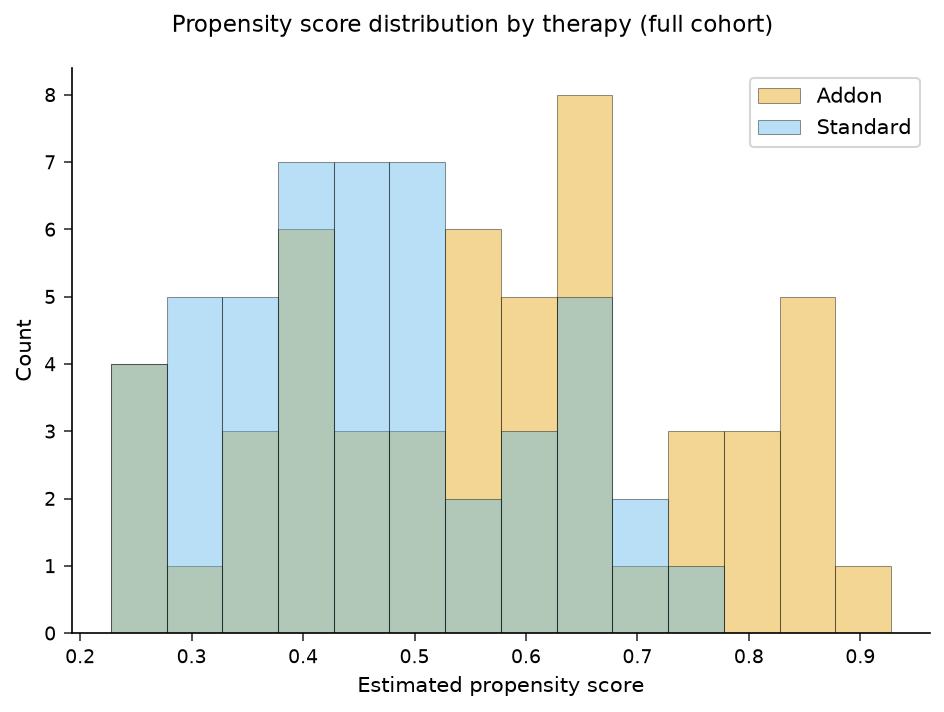

In [4]:
ods graphics on;

proc sgplot data=allps;
   title "Propensity score distribution by therapy (full cohort)";
   histogram _ps_ / group=Therapy transparency=0.4 binwidth=0.05;
   xaxis label="Estimated propensity score";
   yaxis label="Count";
run;

ods graphics off;

### Visualizing balance: standardized differences

The clustered bar chart plots the absolute standardized mean differences from the `ASSESS` table, pre- vs post-match, against the conventional 0.1 threshold (dashed line). The propensity score and logit-PS — the quantities matching targets directly — drop from above 0.16 to below 0.07. The individual covariates were already near balance in this cohort; Age and baseline HbA1c rise modestly after matching, a small-sample artifact of pairing only 32 of 52 treated patients. The values are read straight from the `ASSESS` output above.

NOTE: DATA stddiff

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote stddiff (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=stddiff

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


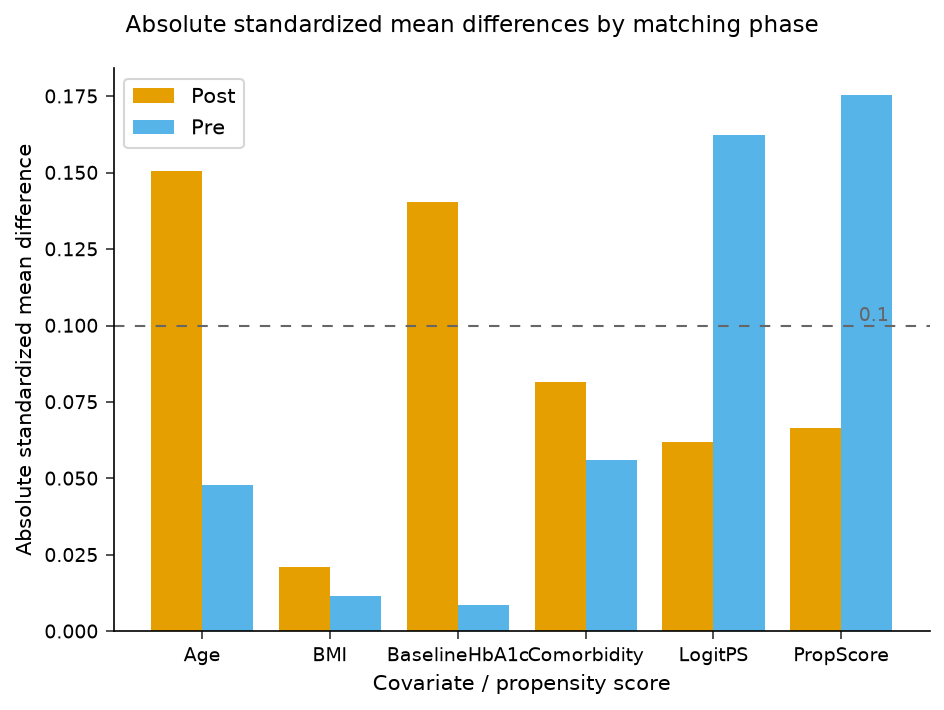

In [5]:
data stddiff;
   length Variable $14 Phase $4;
   input Variable $ Phase $ StdDiff;
   AbsStdDiff = abs(StdDiff);
   datalines;
PropScore Pre 0.1754
PropScore Post 0.0664
LogitPS Pre 0.1624
LogitPS Post 0.0619
Age Pre 0.0477
Age Post -0.1506
BMI Pre 0.0116
BMI Post -0.0210
BaselineHbA1c Pre -0.0086
BaselineHbA1c Post 0.1405
Comorbidity Pre 0.0561
Comorbidity Post -0.0816
;
run;

ods graphics on;

proc sgplot data=stddiff;
   title "Absolute standardized mean differences by matching phase";
   vbar Variable / response=AbsStdDiff group=Phase
                   groupdisplay=cluster;
   refline 0.1 / axis=y lineattrs=(pattern=shortdash) label="0.1";
   yaxis label="Absolute standardized mean difference";
   xaxis label="Covariate / propensity score";
run;

ods graphics off;

## Step 4 — Inspect the matched cohort

Each matched pair shares a `_MatchID`. Listing the first few pairs sorted by match ID confirms that treated and control rows are interleaved, share the same sex (the `EXACT=Sex` constraint), and have nearly identical propensity scores — the row-level sanity check that complements the standardized-difference table from `ASSESS`. The `PROC FREQ` count confirms the matched cohort is balanced 32 vs 32.

In [6]:
proc sort data=matched out=matched_sorted;
   by _MatchID Therapy;
run;

proc print data=matched_sorted(obs=12) noobs;
   var _MatchID PatientID Therapy Sex Age BMI BaselineHbA1c
       _ps_ _MatchWgt;
run;

proc freq data=matched;
   tables Therapy / nocum;
run;


_MATCHID  PATIENTID   THERAPY  SEX  AGE   BMI  BASELINEHBA1C          _PS_  _MATCHWGT
--------  ---------  --------  ---  ---  ----  -------------  ------------  ---------
       1         34  Addon     M     60  28.5            7.2   0.720398989          1
       1         63  Standard  M     61  31.4            7.6  0.7121893443          1
       2         95  Addon     M     52  27.2            7.1  0.6762586334          1
       2          9  Standard  M     44  34.1              7  0.6708733261          1
       3         98  Addon     M     53  27.8            7.7  0.6512503124          1
       3         88  Standard  M     49    30            7.4  0.6471279788          1
       4         49  Addon     M     55  31.9            7.2   0.648169961          1
       4         87  Standard  M     48  27.9            7.7  0.6579705463          1
       5         97  Addon     F     56  31.2            7.2  0.6409774157          1
       5         16  Standard  F     49  31.6        

NOTE: PROC SORT data=matched

NOTE: Read 64 rows from matched.
NOTE: Wrote matched_sorted (64 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=matched_sorted

NOTE: PROC PRINT completed: 12 observations printed, 9 variables
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Step 5 — Estimate the treatment effect on the matched cohort

With balance achieved on the propensity score, a comparison on the matched data approximates a randomized comparison. We re-run the t test on the matched cohort, then fit a covariate-adjusted linear model (`PROC GLM`) for a doubly-robust estimate. Both should fall near the simulated true effect of -0.4 and below the inflated naive estimate from Step 2.

In [7]:
proc ttest data=matched;
   class Therapy;
   var HbA1cChange;
run;

proc glm data=matched;
   class Therapy(ref='Standard') Sex;
   model HbA1cChange = Therapy Sex Age BMI BaselineHbA1c / solution;
run;
quit;

               The TTEST Procedure                
              Variable:  HbA1cChange              

Therapy            N      Mean   Std Dev   Std Err
----------  --------  --------  --------  --------
Addon             32   -0.9659    0.5603    0.0990
Standard          32   -0.6031    0.5959    0.1053
Diff (1-2)             -0.3628                    

Therapy     Lower CL Mean      Mean  Upper CL Mean  Lower CL Std Dev   Std Dev  Upper CL Std Dev
----------  -------------  --------  -------------  ----------------  --------  ----------------
Addon             -1.1679   -0.9659        -0.7639            0.4492    0.5603            0.7449
Standard          -0.8180   -0.6031        -0.3883            0.4777    0.5959            0.7923
Diff (1-2)        -0.6518   -0.3628        -0.0738            0.4921    0.5784            0.7017

Method         Variances        DF   t Value  Pr > |t|
-------------  ---------  --------  --------  --------
Pooled         Equal            62     -2.51 

NOTE: PROC TTEST data=matched

NOTE: PROC TTEST statement used.
NOTE: PROC GLM data=matched

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: PROC GLM statement used.


## Step 6 — A complementary design: propensity-score stratification

Matching discards unmatched patients. **Stratification** keeps everyone: it splits the sample into propensity-score strata and compares treated vs. control within each. `STRATA NSTRATA=5` builds five quintile strata, and `OUTPUT OUT(OBS=ALL)= ... STRATA=` records each patient's stratum for the full cohort so the within-stratum means can be computed. (We request `OUT(OBS=ALL)` so every patient — not just matched ones — is written to the output dataset.)

The five strata hold 28, 28, 16, 18, and 10 patients; the highest-propensity stratum (5) contains only add-on patients, so a within-stratum contrast is available in strata 1–4. This is a useful cross-check on the matched estimate.

In [8]:
proc psmatch data=registry region=allobs;
   class Therapy Sex Comorbidity;
   psmodel Therapy(Treated='Addon') =
           Sex Comorbidity Age BMI BaselineHbA1c;
   strata nstrata=5 key=treated;
   output out(obs=all)=stratified ps=_ps_ strata=_Strata;
run;

proc means data=stratified mean std n maxdec=3;
   class _Strata Therapy;
   var HbA1cChange;
run;


                        The PSMATCH Procedure                         


Data Information
------------------------------------------------------------
Data Set                  registry
Treatment Variable        Therapy
Treated Level             Addon
Observations              100
Treated                   52
Control                   48
In Region                 100

Stratification Summary
------------------------------------------------------------
Number of Strata (nstrata) 5
Stratum   Treated   Control     Total
      1        11        17        28
      2        10        18        28
      3        11         5        16
      4        10         8        18
      5        10         0        10

Propensity Score Summary
------------------------------------------------------------
N                         100
Mean                      0.520000
Min                       0.227490
Max                       0.887720


                                                  The MEANS Pro

NOTE: PROC PSMATCH data=registry

NOTE: PSMATCH OUTPUT dataset stratified written.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

- **Naive estimate (Step 2):** the add-on group started with higher baseline HbA1c (7.23 vs 7.01) and higher BMI (29.6 vs 28.7), so its raw outcome advantage mixes the real drug effect with confounding by indication. The unadjusted t test gives **-0.42** (p = 0.0002).
- **Balance diagnostics (Step 3):** the `ASSESS` standardized-difference table shows the propensity score dropping from 0.175 to 0.066 and the logit propensity score from 0.162 to 0.062 after matching — both below the conventional 0.1 threshold — while the already-small covariate differences stay modest (the bar chart shows Age and baseline HbA1c ticking up slightly post-match, a small-sample artifact of 1:1 caliper matching at n = 32 pairs).
- **Matched effect (Step 5):** the matched t test gives **-0.36** (p = 0.015) and the covariate-adjusted `GLM` gives **-0.32** for the add-on effect (the `therapyStandard` coefficient is +0.318, p = 0.030, so add-on relative to standard is -0.318). Both are smaller in magnitude than the naive -0.42 and bracket the simulated truth of -0.4.
- **Stratification (Step 6):** the within-stratum add-on-minus-standard differences in strata 1–4 (where both arms are present) are -0.56, -0.04, -0.90, and -0.09; averaging them gives roughly -0.4, an independent check that agrees with the matched estimate.

**Takeaway:** `PROC PSMATCH` lets you emulate a randomized comparison from observational registry data. Always validate balance with `ASSESS` *before* examining any outcome — reporting an effect from an imbalanced match is no better than the naive comparison it was meant to fix.